In [1]:
# Import necessary libraries
import csv
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd

import scanpy as sc
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from model.dataset import BagsDataset, custom_collate_fn
from model.model import MIL, EarlyStopping


In [2]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(torch.cuda.current_device())
    print(f"Using device: {device} ({gpu_name})")
else:
    print(f"Using device: {device}")
print("=====================================")


Using device: cpu


In [3]:

# Functions to load gene lists
def load_all_genes(reference_gene_file):
    
    all_genes = pd.read_csv(reference_gene_file)
    all_genes = all_genes['Gene'].values.tolist()
    
    return all_genes


In [15]:
# Set parameters (replace these with your own paths and settings)
# Paths to data and model
data_path = '/project/DPDS/Wang_lab/shared/spatial_TCR/data/train_validate/Visium/HumanOvarianCancer'
reference_gene_path = 'data/human.csv'
pretrained_gene_path = 'data/tumor_antigen_8000.csv'  # Pre-trained gene list
output_dir = os.path.join('fine_tuned_model_by8000', data_path.split('/')[-1])
model_path = 'fine_tuned_model_20000_8000/all_data_human2antigen_40epochs/final_model.pth'  # Set to None if training from scratch


In [119]:

# Training parameters
immune_cell = 'tcell'       # Type of immune cell to consider
learning_rate = 1e-3      # Learning rate for the optimizer
num_epochs = 100          # Number of epochs to train the model
patience = 5                # Patience for early stopping
delta = 0.001               # Minimum change to qualify as an improvement
max_instances = None        # Maximum instances for the dataset
n_genes = 10000             # Number of genes to consider


In [120]:

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load fine-tuning gene list
all_genes = load_all_genes(reference_gene_path)
print('Reference genes loaded:', len(all_genes))
print("=====================================")


Reference genes loaded: 27200


In [121]:

# Load pre-trained gene list
pretrained_genes = load_all_genes(pretrained_gene_path)
print('Pre-trained genes loaded:', len(pretrained_genes))


Pre-trained genes loaded: 8682


In [122]:
common_genes = list(set(pretrained_genes) & set(all_genes))
print(f'Number of common genes: {len(common_genes)}')

Number of common genes: 7451


In [123]:

# Create gene name to index mappings
pretrained_gene_to_index = {gene: idx for idx, gene in enumerate(pretrained_genes)}
fine_tuning_gene_to_index = {gene: idx for idx, gene in enumerate(all_genes)}


In [124]:

# Initialize the model
model = MIL(all_genes).to(device)


In [125]:

# Initialize a new tensor for immunogenicity.ig
new_ig_tensor = model.immunogenicity.ig.data.clone()


In [126]:

# Load pre-trained model's state dict
pretrained_state_dict = torch.load(model_path, map_location=device)


In [127]:

# Get the pre-trained immunogenicity.ig tensor
pretrained_ig_tensor = pretrained_state_dict['immunogenicity.ig']


In [128]:

# Copy over the values for common genes
for gene in common_genes:
    pretrained_idx = pretrained_gene_to_index[gene]
    fine_tuning_idx = fine_tuning_gene_to_index[gene]
    new_ig_tensor[fine_tuning_idx] = pretrained_ig_tensor[pretrained_idx]

# Assign the new tensor to the model
with torch.no_grad():
    model.immunogenicity.ig.copy_(new_ig_tensor)

print("Copied immunogenicity.ig values for common genes.")


Copied immunogenicity.ig values for common genes.


In [129]:

# Remove immunogenicity.ig from the pre-trained state dict
pretrained_state_dict.pop('immunogenicity.ig', None)


tensor([-1.0000, -1.0000, -2.7507,  ...,  4.3413,  5.6221,  6.3630])

In [130]:

# Load other compatible parameters
model_state_dict = model.state_dict()
common_keys = [k for k in pretrained_state_dict.keys()
               if k in model_state_dict and pretrained_state_dict[k].size() == model_state_dict[k].size()]
filtered_pretrained_state_dict = {k: pretrained_state_dict[k] for k in common_keys}
model_state_dict.update(filtered_pretrained_state_dict)
model.load_state_dict(model_state_dict)

print(f"Loaded matching model weights from {model_path} (excluding immunogenicity.ig).")


Loaded matching model weights from fine_tuned_model_20000_8000/all_data_human2antigen_40epochs/final_model.pth (excluding immunogenicity.ig).


In [131]:
model.state_dict()

OrderedDict([('alpha', tensor(4.4051)),
             ('beta', tensor(-5.3858)),
             ('distance.a', tensor(-9.9177)),
             ('gene_expression.b', tensor(-5.8433)),
             ('immunogenicity.ig',
              tensor([-1.0000, -0.0873, -1.0000,  ..., -1.0000, -1.0000, -1.0000]))])

In [132]:
model.alpha = nn.Parameter(torch.tensor(1.0), requires_grad=True)
model.beta = nn.Parameter(torch.tensor(1.0), requires_grad=True)
model.distance.a = nn.Parameter(torch.tensor(1.0), requires_grad=True)
model.gene_expression.b = nn.Parameter(torch.tensor(1.0), requires_grad=True)


In [133]:
model.state_dict()

OrderedDict([('alpha', tensor(1.)),
             ('beta', tensor(1.)),
             ('distance.a', tensor(1.)),
             ('gene_expression.b', tensor(1.)),
             ('immunogenicity.ig',
              tensor([-1.0000, -0.0873, -1.0000,  ..., -1.0000, -1.0000, -1.0000]))])

In [134]:

# Optionally freeze pre-trained parameters (excluding immunogenicity.ig)
# for name, param in model.named_parameters():
#     if name in filtered_pretrained_state_dict:
#         param.requires_grad = False

# Define loss criterion and optimizer
criterion = nn.BCELoss().to(device)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)


In [135]:

# Load dataset
# Replace 'BagsDataset' and 'custom_collate_fn' with your data loading functions
adata = sc.read(os.path.join(data_path, 'T_cell.h5ad'))
dataset = BagsDataset(adata, immune_cell=immune_cell, max_instances=max_instances, n_genes=n_genes, radius=300, resolution='low')
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True, collate_fn=custom_collate_fn)


Tumor cells shape after filtering: (1226, 17943)
Selecting top 10000 genes based on mean expression
Top 10000 genes: Index(['IGHM', 'IGLC1', 'IGKC', 'JCHAIN', 'B2M', 'TMSB4X', 'UBC', 'UBA52',
       'ACTB', 'FTL',
       ...
       'ADCY4', 'GPR75', 'KDM4A', 'MKX', 'MYPOP', 'NAV1', 'IZUMO4', 'UBE2L3',
       'LMOD1', 'CCDC153'],
      dtype='object', length=10000)
Percentile value: 4.037618160247803
adata.obs[T] after binarization: AAACAAGTATCTCCCA-1    0
AAACAATCTACTAGCA-1    0
AAACACCAATAACTGC-1    1
AAACAGAGCGACTCCT-1    1
AAACAGCTTTCAGAAG-1    0
Name: T, dtype: int64
Preprocessed data: (3455, 10000)


Creating Bags with radius 300: 100%|██████████████████████████| 3455/3455 [00:00<00:00, 9614.00it/s]

Total bags created: 1226
Average instances per bag: 10


In [136]:

# Initialize early stopping
early_stopping = EarlyStopping(patience=patience, delta=delta)

# Store IG scores before training
ig_scores_before_training = torch.sigmoid(model.immunogenicity.ig.detach().cpu())


In [137]:
# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    gradients = {}

    with tqdm(train_loader, unit="batch") as tepoch:
        for i, (distances, gene_expressions, label, core_idx, gene_names, cell_ids) in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}/{num_epochs}")

            optimizer.zero_grad()

            distances = torch.stack(distances).to(device)
            gene_expressions = torch.stack(gene_expressions).to(device)
            label = label.clone().detach().float().to(device)

            output = model(distances, gene_expressions, list(gene_names[0]))

            loss = criterion(output, label)
            loss.backward()
            
            # Checking gradients
            for name, param in model.named_parameters():
                if param.grad is not None:
                    if name not in gradients:
                        gradients[name] = []
                    gradients[name].append(param.grad.cpu().numpy())

            optimizer.step()

            running_loss += loss.item()
            tepoch.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')
    for name, grad_list in gradients.items():
        grad_array = np.array(grad_list)
        np.save(f"gradients/epoch_{epoch+1}_{name}.npy", grad_array)

    # Validation
    model.eval()
    val_loss = 0.0
    val_predictions = []
    val_labels = []
    with torch.no_grad():
        for val_distances, val_gene_expressions, val_label, _, val_gene_names, val_cell_ids in val_loader:
            val_distances = torch.stack(val_distances).to(device)
            val_gene_expressions = torch.stack(val_gene_expressions).to(device)
            val_label = val_label.clone().detach().float().to(device)
            val_output = model(val_distances, val_gene_expressions, list(val_gene_names[0]))
            val_loss += criterion(val_output, val_label).item()
            val_predictions.extend(val_output.cpu().numpy())
            val_labels.extend(val_label.cpu().numpy())

    val_loss /= len(val_loader)
    val_auroc = roc_auc_score(val_labels, val_predictions)
    print(f'Validation Loss: {val_loss:.4f}, Validation AUROC: {val_auroc:.4f}')
    
    # Early stopping
    early_stopping(val_loss, model, epoch)
    if epoch >= 10:
        if early_stopping.early_stop:
            print(f'Early stopping at epoch {epoch+1}')
            break


Epoch 1/100: 100%|██████████| 858/858 [00:08<00:00, 96.53batch/s, loss=0.348] 


Epoch [1/100], Loss: 0.8473
Validation Loss: 0.8518, Validation AUROC: 0.4414


Epoch 2/100: 100%|██████████| 858/858 [00:08<00:00, 96.21batch/s, loss=0.413] 


Epoch [2/100], Loss: 0.7976
Validation Loss: 0.8061, Validation AUROC: 0.4425


Epoch 3/100: 100%|██████████| 858/858 [00:08<00:00, 95.64batch/s, loss=0.403] 


...

Epoch [26/100], Loss: 0.7032
Validation Loss: 0.7050, Validation AUROC: 0.4435


Epoch 27/100: 100%|██████████| 858/858 [00:08<00:00, 97.63batch/s, loss=0.677] 


Epoch [27/100], Loss: 0.7031
Validation Loss: 0.7048, Validation AUROC: 0.4434


Epoch 28/100: 100%|██████████| 858/858 [00:08<00:00, 98.32batch/s, loss=0.679] 


Epoch [28/100], Loss: 0.7029
Validation Loss: 0.7046, Validation AUROC: 0.4435
Early stopping at epoch 28


Layer: epoch_10_alpha
  mean: 0.002807
  std: 0.023946
  max: 0.072422
  min: -0.069297
  norm: 0.706230

Layer: epoch_9_gene_expression
  mean: 0.000232
  std: 0.032042
  max: 0.056463
  min: -0.060937
  norm: 0.938601

Layer: epoch_5_alpha
  mean: 0.003312
  std: 0.027362
  max: 0.085046
  min: -0.079447
  norm: 0.807342

Layer: epoch_11_gene_expression
  mean: -0.000004
  std: 0.030670
  max: 0.054611
  min: -0.057626
  norm: 0.898386

Layer: epoch_9_immunogenicity
  mean: 0.000000
  std: 0.000046
  max: 0.030318
  min: -0.025444
  norm: 0.220642

Layer: epoch_10_distance
  mean: 0.000000
  std: 0.000000
  max: -0.000000
  min: -0.000000
  norm: 0.000000

Layer: epoch_9_alpha
  mean: 0.002772
  std: 0.024450
  max: 0.073567
  min: -0.072554
  norm: 0.720762

Layer: epoch_2_alpha
  mean: 0.003587
  std: 0.029770
  max: 0.090168
  min: -0.087525
  norm: 0.878309

Layer: epoch_1_alpha
  mean: 0.003943
  std: 0.030930
  max: 0.095056
  min: -0.087195
  norm: 0.913312

Layer: epoch_1_dis

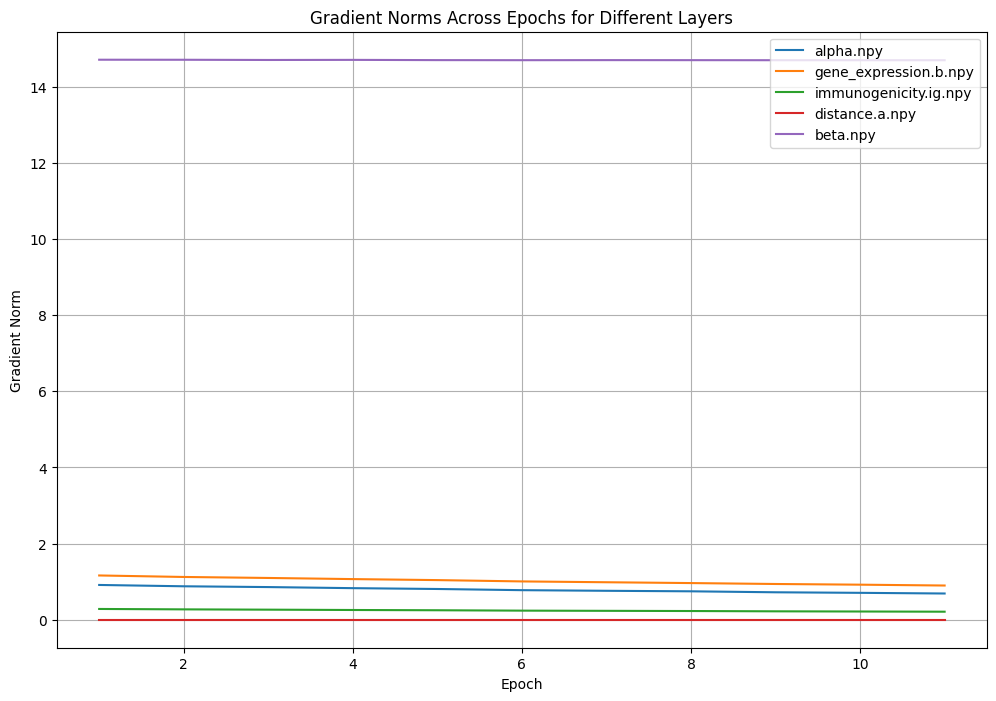

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Set the directory where gradients are stored
gradient_dir = "gradients"

# Function to load and analyze gradients
def analyze_gradients(gradient_dir):
    # Initialize a dictionary to store analysis results
    grad_stats = {}

    # Iterate over gradient files
    for filename in os.listdir(gradient_dir):
        if filename.endswith(".npy"):
            layer_name = filename.split('.')[0]
            file_path = os.path.join(gradient_dir, filename)
            
            # Load the gradient array
            grad_array = np.load(file_path)

            # Calculate gradient statistics
            grad_mean = np.mean(grad_array)
            grad_std = np.std(grad_array)
            grad_max = np.max(grad_array)
            grad_min = np.min(grad_array)
            grad_norm = np.linalg.norm(grad_array)
            
            # Store statistics in the dictionary
            grad_stats[layer_name] = {
                "mean": grad_mean,
                "std": grad_std,
                "max": grad_max,
                "min": grad_min,
                "norm": grad_norm
            }
    
    return grad_stats

# Run gradient analysis
grad_stats = analyze_gradients(gradient_dir)

# Print gradient analysis results
for layer, stats in grad_stats.items():
    print(f"Layer: {layer}")
    for stat_name, value in stats.items():
        print(f"  {stat_name}: {value:.6f}")
    print()

# Function to visualize the gradient norms over epochs
def plot_gradient_norms(gradient_dir):
    # Initialize a dictionary to store gradient norms for each epoch
    epoch_norms = {}

    # Iterate over gradient files to collect norms
    for filename in os.listdir(gradient_dir):
        if filename.endswith(".npy"):
            layer_name = "_".join(filename.split('_')[2:])  # Extract layer name (excluding epoch number)
            epoch_num = int(filename.split('_')[1].replace('epoch', ''))

            file_path = os.path.join(gradient_dir, filename)
            grad_array = np.load(file_path)

            grad_norm = np.linalg.norm(grad_array)
            
            # Add gradient norm to the corresponding layer's list
            if layer_name not in epoch_norms:
                epoch_norms[layer_name] = []
            epoch_norms[layer_name].append((epoch_num, grad_norm))

    # Plot the gradient norms across epochs for each layer
    plt.figure(figsize=(12, 8))
    for layer, norms in epoch_norms.items():
        norms = sorted(norms, key=lambda x: x[0])  # Sort by epoch number
        epochs, norms_values = zip(*norms)
        plt.plot(epochs, norms_values, label=layer)

    plt.xlabel('Epoch')
    plt.ylabel('Gradient Norm')
    plt.title('Gradient Norms Across Epochs for Different Layers')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

# Run the visualization for gradient norms
plot_gradient_norms(gradient_dir)


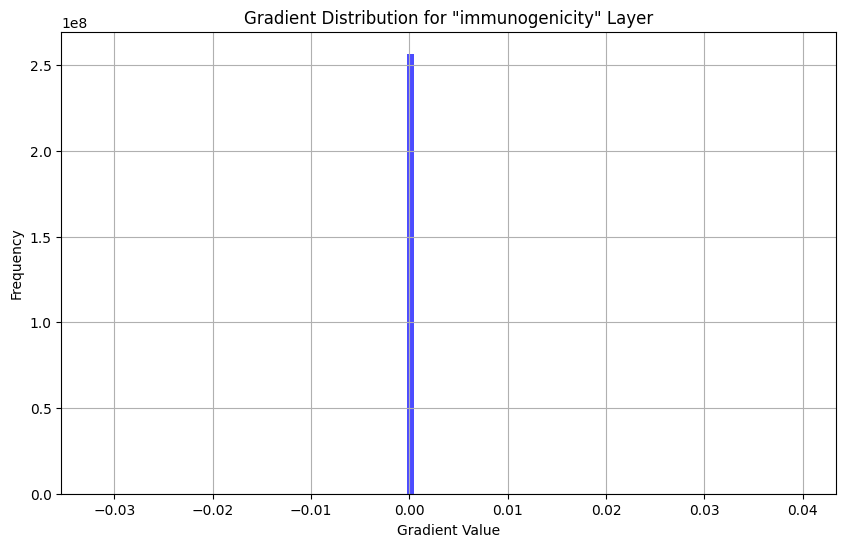

In [42]:
def load_immunogenicity_gradients(gradient_dir):
    immunogenicity_gradients = []

    # Iterate over gradient files to find those related to "immunogenicity"
    for filename in os.listdir(gradient_dir):
        if "immunogenicity" in filename and filename.endswith(".npy"):
            file_path = os.path.join(gradient_dir, filename)
            grad_array = np.load(file_path)
            immunogenicity_gradients.extend(grad_array.flatten())

    return immunogenicity_gradients

# Load gradients for the "immunogenicity" layer
immunogenicity_gradients = load_immunogenicity_gradients(gradient_dir)

# Plot the gradient distribution histogram
plt.figure(figsize=(10, 6))
plt.hist(immunogenicity_gradients, bins=100, color='blue', alpha=0.7)
plt.xlabel('Gradient Value')
plt.ylabel('Frequency')
plt.title('Gradient Distribution for "immunogenicity" Layer')
plt.grid(True)
plt.show()

In [392]:

# Store IG scores after training
ig_scores_after_training = torch.sigmoid(model.immunogenicity.ig.detach().cpu())

# Create DataFrame for IG scores
ig_score = {
    'Gene': all_genes,
    'IG Score Before Training': ig_scores_before_training.numpy(),
    'IG Score After Training': ig_scores_after_training.numpy()
}
df = pd.DataFrame(ig_score)

# Calculate the difference and add it as a new column
df['Difference'] = df['IG Score After Training'] - df['IG Score Before Training']

# Sort the DataFrame by the Difference column in descending order
df = df.sort_values(by='Difference', ascending=False)

# Write the sorted DataFrame to a CSV file
output_path = os.path.join(output_dir, 'ig_score_changes.csv')
df.to_csv(output_path, index=False)

# Save the final model
torch.save(model.state_dict(), os.path.join(output_dir, 'final_model.pth'))

print("Training complete. Model and IG scores saved.")

Training complete. Model and IG scores saved.


In [393]:
output_dir

'fine_tuned_model_by8000/HumanOvarianCancer'

In [ ]:
绘制 immunogenicity 层的梯度分布直方图